Spectral data:   0%|          | 0/101 [00:00<?, ?it/s]

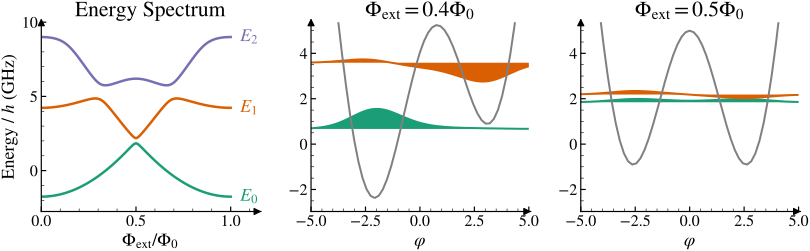

In [7]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
import scqubits as scq

# ==============================================================================
# Apply "small_plot" aesthetics scaled for three horizontal panels
# ==============================================================================
sz = 4.0
colors = ['#1b9e77', '#d95f02', '#7570b3']

mpl.rcParams.update({
    "figure.figsize": (sz * 3, sz), 
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "font.family": "STIXGeneral",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "mathtext.fontset": "stix",

    "lines.linewidth": 2.0,
    "lines.markersize": 5.0,

    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3.0,
    "ytick.minor.size": 3.0,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
    
    # Force default color sequence universally
    "axes.prop_cycle": cycler(color=colors),
    
    "svg.fonttype": "path",
    "pdf.fonttype": 42
})

def add_axis_arrows(ax, arrow_lw=1.2, arrow_color="black", arrow_scale=1.5):
    """Add arrowheads to axes."""
    ax.annotate("", xy=(1.02, 0.0), xytext=(1.0, 0.0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", lw=arrow_lw, color=arrow_color, mutation_scale=10 * arrow_scale))
    ax.annotate("", xy=(0.0, 1.02), xytext=(0.0, 1.0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", lw=arrow_lw, color=arrow_color, mutation_scale=10 * arrow_scale))

# ==============================================================================
# Model Definition
# ==============================================================================
EJ = 5.0  # GHz
EC = 1.0  # GHz
EL = 1.0  # GHz

fluxonium = scq.Fluxonium(
    EJ=EJ,
    EC=EC,
    EL=EL,
    flux=0.0,
    cutoff=110
)

# ==============================================================================
# Plot Generation
# ==============================================================================
fig, axes = plt.subplots(1, 3)

# ----------------- Panel 1: Energy Spectrum -----------------
flux_vals = np.linspace(0.0, 1.0, 101)
specdata = fluxonium.get_spectrum_vs_paramvals(
    'flux', flux_vals, evals_count=3, subtract_ground=False
)

for n in range(3):
    y_vals = specdata.energy_table[:, n]
    axes[0].plot(flux_vals, y_vals, color=colors[n], lw=2.5)
    
    # Direct styling label at Phi = 1.0
    axes[0].text(flux_vals[-1] + 0.05, y_vals[-1], rf'$E_{n}$', color=colors[n], va='center', ha='left')

axes[0].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$')
axes[0].set_ylabel(r'Energy / $h$ (GHz)')
axes[0].set_title(r'Energy Spectrum')
axes[0].set_xlim(0.0, 1.15)
axes[0].set_ylim(np.min(specdata.energy_table) - 1.0, np.max(specdata.energy_table[:, :3]) + 1.0)
add_axis_arrows(axes[0])


# ----------------- Panel 2: Tilted Double Well -----------------
fluxonium.flux = 0.4
# Force properties cycler so wavefunction 0 adopts colors[0], and 1 adopts colors[1]
axes[1].set_prop_cycle(cycler(color=colors))
fluxonium.plot_wavefunction(which=[0, 1], fig_ax=(fig, axes[1]))

axes[1].set_title(r'$\Phi_{\mathrm{ext}} = 0.4 \Phi_0$')
axes[1].set_xlabel(r'$\varphi$')
axes[1].set_xlim(-5, 5)

axes[1].set_ylabel("") # Only hide the text label, keeping the axis line
add_axis_arrows(axes[1]) 


# ----------------- Panel 3: Symmetric Double Well -----------------
fluxonium.flux = 0.5
# Force properties cycler
axes[2].set_prop_cycle(cycler(color=colors))
fluxonium.plot_wavefunction(which=[0, 1], fig_ax=(fig, axes[2]))

axes[2].set_title(r'$\Phi_{\mathrm{ext}} = 0.5 \Phi_0$')
axes[2].set_xlabel(r'$\varphi$')
axes[2].set_xlim(-5, 5)

axes[2].set_ylabel("") # Only hide the text label, keeping the axis line
add_axis_arrows(axes[2]) 


# Synchronize internal limits so wavefunctions are perfectly comparable inside
y_min_1, y_max_1 = axes[1].get_ylim()
y_min_2, y_max_2 = axes[2].get_ylim()
axes[1].set_ylim(min(y_min_1, y_min_2), max(y_max_1, y_max_2))
axes[2].set_ylim(min(y_min_1, y_min_2), max(y_max_1, y_max_2))

fig.tight_layout()
fig.savefig('fluxonium_full_panel.pdf')
plt.show()
